# Jurnal Modul 3 Perbaikan Kualitas dan Deteksi Tepi #

# Import Library # 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

numpy digunakan untuk operasi matriks dan array.
matplotlib.pyplot digunakan untuk menampilkan citra.
cv2 (OpenCV) digunakan untuk membaca dan memproses citra.
Library ini akan digunakan pada proses selanjutnya seperti membaca gambar, konversi citra, filtering, dan deteksi tepi.

# Membaca dan menampilkan citra Awal#

Pada tahap ini dilakukan proses pembacaan citra menggunakan `cv2.imread`, kemudian citra dikonversi ke dua format warna yaitu grayscale dan RGB. 
Konversi ke grayscale (`cv2.COLOR_BGR2GRAY`) digunakan untuk keperluan pemrosesan citra seperti deteksi tepi atau filtering, karena hanya membutuhkan intensitas cahaya tanpa informasi warna.
Sedangkan konversi ke RGB (`cv2.COLOR_BGR2RGB`) dilakukan agar citra dapat ditampilkan dengan benar menggunakan `matplotlib`, karena OpenCV secara default membaca citra dalam format BGR.
Selanjutnya, ukuran citra ditampilkan menggunakan `shape` untuk mengetahui dimensi gambar. 
Kemudian citra ditampilkan menggunakan `plt.imshow` dengan judul "Citra Awal" sebagai referensi sebelum dilakukan proses pengolahan lebih lanjut.

(450, 800, 3)


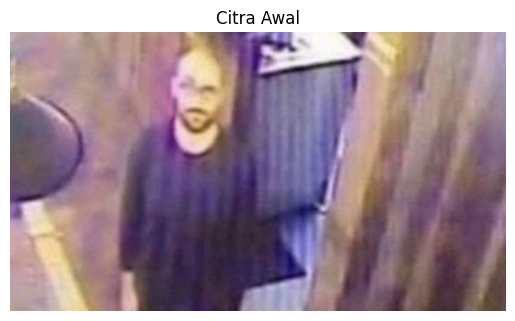

In [3]:
Objek1 = cv2.imread('backup.jpg')
GambarGray = cv2.cvtColor(Objek1, cv2.COLOR_BGR2GRAY)

gambarRGB = cv2.cvtColor(Objek1, cv2.COLOR_BGR2RGB)
print(gambarRGB.shape)
plt.title("Citra Awal")
plt.imshow(gambarRGB, cmap='gray')
plt.axis('off')
plt.show()

# Membaca dan menampilkan citra grayscale #
Pada bagian ini, citra dibaca langsung dalam format grayscale menggunakan `cv2.imread` dengan parameter `cv2.IMREAD_GRAYSCALE`. Hal ini membuat citra hanya memiliki satu kanal intensitas (keabuan), sehingga lebih sederhana untuk proses pengolahan seperti thresholding dan deteksi tepi.
Ukuran citra kemudian ditampilkan menggunakan `shape` untuk mengetahui dimensi tinggi dan lebar gambar.
Selanjutnya, citra grayscale ditampilkan menggunakan `matplotlib` dengan `cmap='gray'` agar representasi tingkat keabuan terlihat dengan benar. Judul "Citra Grayscale" diberikan untuk membedakan dari citra awal berwarna.

(450, 800)


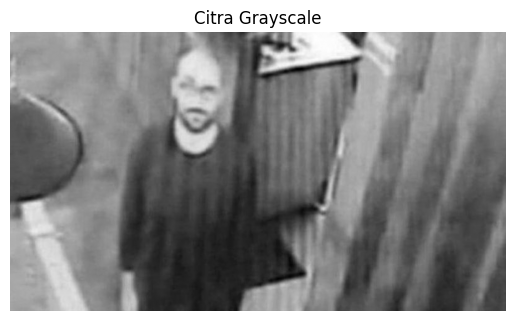

In [4]:
gray1 = cv2.imread('backup.jpg', cv2.IMREAD_GRAYSCALE)
print(gray1.shape)
plt.title("Citra Grayscale")
plt.imshow(gray1, cmap='gray')
plt.axis('off')
plt.show()

# Implementasi Konvolusi #

In [5]:
def convolution(gray1, kernel):

    size = kernel.shape[0]

    pad_size = size // 2

    padded = np.pad(gray1, pad_size, mode='constant')

    canvas = np.zeros_like(gray1).astype(np.float32)

    height, width = gray1.shape

    for i in range(height):

        for j in range(width):
        
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

Fungsi ini digunakan untuk melakukan proses konvolusi antara citra grayscale dengan kernel (filter). Konvolusi dipakai untuk berbagai proses seperti deteksi tepi, smoothing, dan sharpening.
Citra terlebih dahulu diberi padding menggunakan `np.pad` agar proses konvolusi bisa dilakukan hingga ke bagian tepi gambar.
Kemudian dilakukan perulangan untuk mengambil bagian kecil citra (region) sesuai ukuran kernel, lalu dikalikan dengan kernel dan dijumlahkan.
Hasilnya disimpan pada variabel `canvas` sebagai citra baru hasil konvolusi.

# Kernel Smoothing dan Sharpening #

In [6]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

Pada bagian ini dibuat dua jenis kernel yang digunakan untuk proses filtering citra.

`kernelSmoothing` digunakan untuk menghaluskan citra dengan cara meratakan nilai piksel di sekitarnya, sehingga noise atau detail kecil dapat dikurangi.
Sedangkan `kernelSharpening` digunakan untuk mempertajam citra dengan memperkuat bagian tengah (piksel utama) dibandingkan sekitarnya, sehingga tepi atau detail objek menjadi lebih jelas.

# CCTV : Smoothing, Sharpening dan Kombinasi #

Pada kode ini dilakukan filtering citra menggunakan fungsi convolution dengan dua kernel, yaitu smoothing dan sharpening.
`hasil_smoothing` digunakan untuk menghaluskan citra sehingga noise berkurang dan gambar terlihat lebih lembut.
`hasil_sharpening` digunakan untuk mempertajam citra sehingga tepi dan detail objek menjadi lebih jelas.
Selain itu, dilakukan kombinasi smoothing lalu sharpening untuk mendapatkan hasil yang lebih bersih namun tetap tajam.

Perbedaannya terletak pada tujuan: smoothing untuk menghaluskan, sharpening untuk menajamkan, dan kombinasi untuk menyeimbangkan keduanya.

# Perbedaan Mean, Median, dan Modus

1. Mean  
Mengambil rata-rata nilai piksel. Hasil halus, tapi sensitif terhadap noise.

2. Median  
Mengambil nilai tengah. Lebih baik untuk menghilangkan noise (terutama salt & pepper).

3. Modus  
Mengambil nilai yang paling sering muncul. Jarang digunakan karena kurang stabil pada citra kompleks.

Perbedaannya: mean lebih halus tapi mudah terpengaruh noise, median lebih tahan noise, dan modus fokus pada nilai dominan.



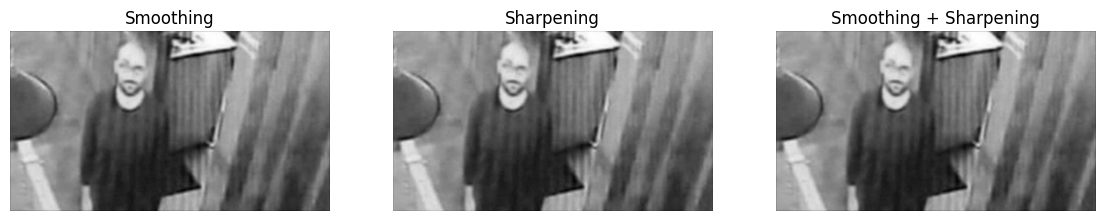

In [7]:
hasil_smoothing = convolution(gray1, kernelSmoothing)
hasil_sharpening = convolution(gray1, kernelSharpening)

Smoothing_Sharpening = convolution(gray1, kernelSmoothing)
Smoothing_Sharpening1 = convolution(Smoothing_Sharpening, kernelSharpening)

plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
plt.imshow(hasil_smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(hasil_sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(Smoothing_Sharpening, cmap='gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')

plt.show()

# Kernel Sobel #

In [8]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np. array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

Pada bagian ini dibuat dua kernel Sobel, yaitu `sobelX` dan `sobelY`, yang digunakan untuk mendeteksi tepi pada citra.

`sobelX` berfungsi untuk mendeteksi perubahan intensitas secara horizontal (tepi vertikal), sehingga bisa menangkap sisi kiri dan kanan objek.

`sobelY` berfungsi untuk mendeteksi perubahan intensitas secara vertikal (tepi horizontal), sehingga bisa menangkap bagian atas dan bawah objek.

# Kernel Prewit #

In [9]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

Pada bagian ini dibuat kernel Prewitt, yaitu `prewittX` dan `prewittY`, yang digunakan untuk mendeteksi tepi pada citra.

`prewittX` digunakan untuk mendeteksi perubahan intensitas secara horizontal (tepi vertikal), sehingga dapat menangkap sisi kiri dan kanan objek.

`prewittY` digunakan untuk mendeteksi perubahan intensitas secara vertikal (tepi horizontal), sehingga dapat menangkap bagian atas dan bawah objek.

# Kernel Roberts 

In [10]:
robertsX = np. array([
    [1,  0],
    [0, -1],
], dtype=np. float32)

robertsY = np. array ([
    [0,  1],
    [-1, 0], 
], dtype=np. float32)

Pada bagian ini digunakan kernel Roberts, yaitu `robertsX` dan `robertsY`, untuk mendeteksi tepi pada citra.

`robertsX` digunakan untuk mendeteksi perubahan intensitas secara diagonal (dari kiri atas ke kanan bawah).

`robertsY` digunakan untuk mendeteksi perubahan intensitas secara diagonal sebaliknya (dari kanan atas ke kiri bawah).

# Deteksi Tepi 

In [75]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np. zeros_like(img, dtype=np. float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max (canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi `edge(img, kernelx, kernely)` digunakan untuk mendeteksi tepi pada citra dengan memanfaatkan dua kernel (arah X dan Y).

Pertama, citra dikonvolusi dengan `kernelx` untuk mendapatkan gradien horizontal (`gx`), dan dengan `kernely` untuk mendapatkan gradien vertikal (`gy`).

Kemudian kedua hasil tersebut digabungkan menggunakan nilai absolut (`|gx| + |gy|`) untuk mendapatkan kekuatan tepi secara keseluruhan.

Hasilnya lalu dinormalisasi ke rentang 0–255 agar dapat ditampilkan sebagai citra grayscale.

Fungsi ini menghasilkan citra tepi yang menonjolkan batas objek sehingga bentuk objek lebih mudah dikenali.

# Deteksi Tepi dengan Prewitt, Sobel, dan Roberts

Pada bagian ini dilakukan deteksi tepi menggunakan tiga operator yaitu Prewitt, Sobel, dan Roberts pada citra hasil smoothing (`hasil_smoothing`).

- `hasil_prewitt` menggunakan operator Prewitt untuk mendeteksi tepi secara sederhana berdasarkan perubahan intensitas horizontal dan vertikal.
- `hasil_sobel` menggunakan operator Sobel yang lebih sensitif karena memberikan bobot lebih besar di tengah kernel, sehingga hasil tepi lebih tegas.
- `hasil_roberts` menggunakan operator Roberts yang mendeteksi tepi secara diagonal dengan kernel kecil (2x2), sehingga lebih tajam namun sensitif terhadap noise.

Selanjutnya dilakukan kombinasi beberapa operator:
Kombinasi digunakan untuk meningkatkan kualitas deteksi tepi, karena tiap operator punya kelebihan masing-masing.
Prewitt memberi dasar, Sobel memperkuat, Roberts menambahkan detail kecil.

- `Prewitt + Sobel`: hasil Prewitt diproses lagi dengan Sobel untuk mempertegas tepi.
- `Prewitt + Roberts`: hasil Prewitt dipertajam dengan Roberts sehingga tepi menjadi lebih tajam.
- `Sobel + Roberts`: Sobel digunakan dulu untuk tepi kuat, lalu Roberts untuk detail kecil.
- `Prewitt + Sobel + Roberts`: kombinasi bertahap untuk mendapatkan tepi yang semakin detail dan kompleks.



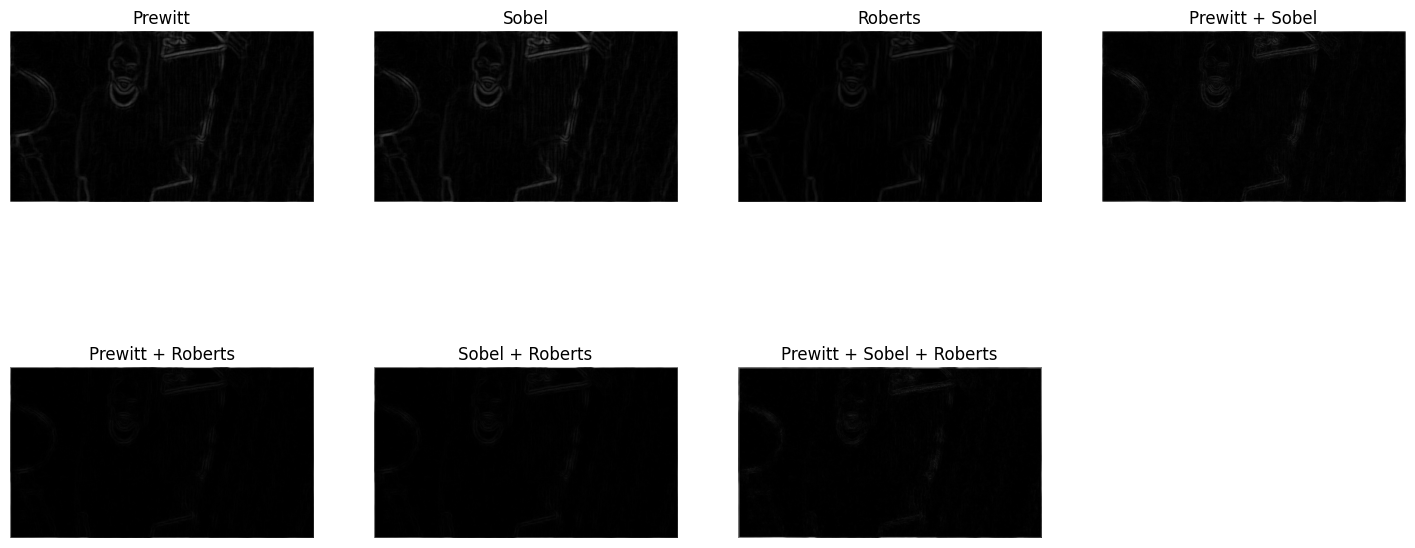

In [12]:
hasil_prewitt = edge(hasil_smoothing, prewittX, prewittY)
hasil_sobel   = edge(hasil_smoothing, sobelX, sobelY)
hasil_roberts = edge(hasil_smoothing, robertsX, robertsY)

PrewittSobel = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobel1 = edge (PrewittSobel, sobelX, sobelY)

PrewittRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittRobert1 = edge (PrewittRobert, robertsX, robertsY)

SobelRobert = edge (Smoothing_Sharpening, sobelX, sobelY)
SobelRobert1 = edge (SobelRobert, robertsX, robertsY)

PrewittSobelRobert = edge (Smoothing_Sharpening, prewittX, prewittY)
PrewittSobelRobert1 = edge (PrewittSobelRobert, sobelX, sobelY)
PrewittSobelRobert2 = edge(PrewittSobelRobert1, robertsX, robertsY)

plt.figure(figsize=(18,8))

plt.subplot(2,4,1)
plt.imshow(hasil_prewitt, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(hasil_sobel, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(hasil_roberts, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(PrewittSobel1, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(PrewittRobert1, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(SobelRobert1, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(PrewittSobelRobert2, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

plt.show()

# Threshold Manual

In [13]:
def threshold_manual(img, t):
    height, width = img.shape
    result = np.zeros_like(img)

    for i in range(height):
        for j in range(width):
            if img[i, j] > t:
                result[i, j] = 255
            else:
                result[i, j] = 0

    return result

Kode ini digunakan untuk mengubah citra grayscale menjadi citra biner (hitam-putih) berdasarkan nilai ambang (threshold) tertentu.

Fungsi `threshold_manual(img, t)` bekerja dengan cara:
- Membaca setiap piksel pada citra (`img`)
- Jika nilai piksel lebih besar dari threshold `t`, maka diubah menjadi putih (255)
- Jika tidak, maka diubah menjadi hitam (0)

Hasilnya adalah citra yang hanya memiliki dua nilai (0 dan 255), sehingga memudahkan proses segmentasi objek (misalnya memisahkan objek dari background).

 # CCTV: Perbandingan Threshold Tepi 

Pada kode ini dilakukan proses thresholding pada citra hasil deteksi tepi Sobel (`hasil_sobel`) dengan beberapa nilai ambang, yaitu 10, 20, 30, 40, 50, dan 60.

Setiap nilai threshold digunakan untuk mengubah citra menjadi biner. Piksel dengan nilai lebih besar dari threshold akan menjadi putih (tepi), sedangkan sisanya menjadi hitam (background). Hasilnya ditampilkan untuk melihat perbedaan tiap nilai threshold.

Penggunaan threshold sangat berpengaruh terhadap hasil deteksi tepi:

- Threshold rendah (10–20) menghasilkan banyak piksel putih, sehingga hampir semua tepi termasuk noise ikut terdeteksi. Gambar terlihat lebih ramai dan kurang bersih.
- Threshold sedang (30–40) mulai menyeleksi tepi yang lebih jelas, sehingga objek masih terlihat lengkap tetapi noise mulai berkurang.
- Threshold tinggi (50–60) hanya menampilkan tepi yang kuat saja. Hasil lebih bersih, tetapi beberapa detail penting bisa hilang.

Perbedaan mencoloknya adalah:
- Threshold rendah → detail banyak tapi berisik (noise tinggi)
- Threshold tinggi → bersih tapi detail berkurang

Untuk kasus ini, threshold yang paling baik adalah sekitar **30 atau 40**, karena masih mempertahankan bentuk objek dengan cukup jelas tanpa terlalu banyak noise. Nilai ini memberikan keseimbangan antara detail dan kebersihan hasil citra.

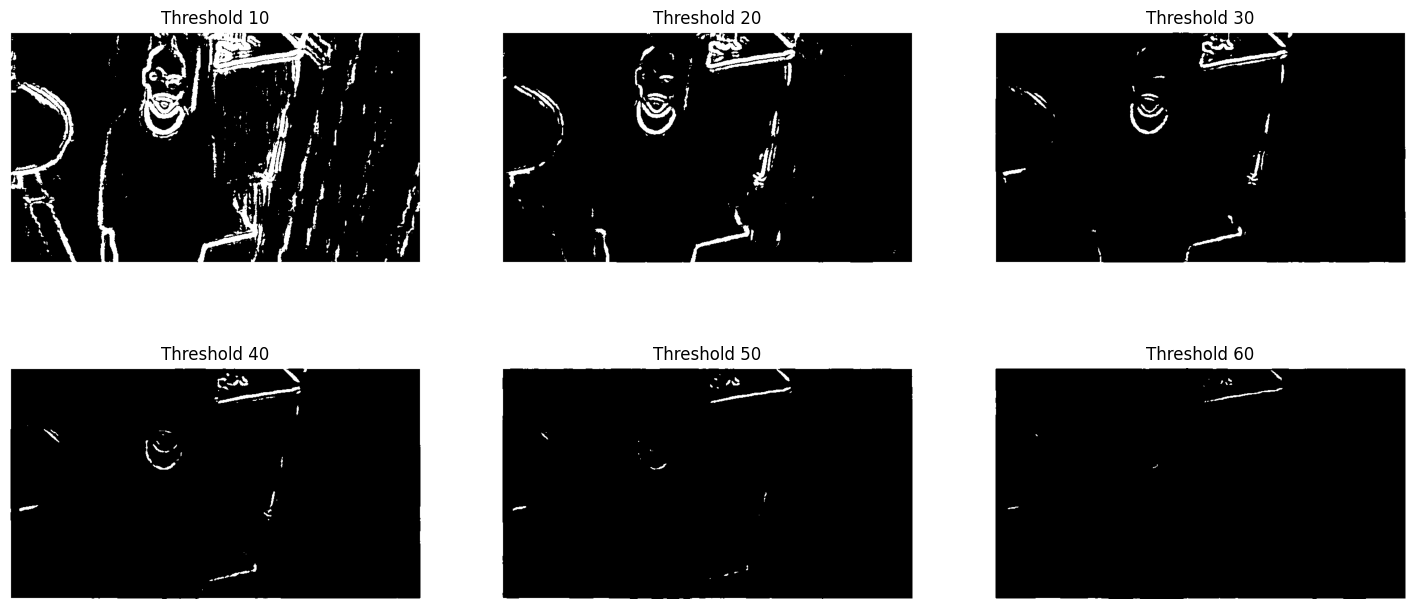

In [73]:
img_edge = hasil_sobel  

t10 = threshold_manual(img_edge, 10)
t20 = threshold_manual(img_edge, 20)
t30 = threshold_manual(img_edge, 30)
t40 = threshold_manual(img_edge, 40)
t50 = threshold_manual(img_edge, 50)
t60 = threshold_manual(img_edge, 60)

plt.figure(figsize=(18,8))

plt.subplot(2,3,1)
plt.imshow(t10, cmap='gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(t20, cmap='gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(t30, cmap='gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(t40, cmap='gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(t50, cmap='gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(t60, cmap='gray')
plt.title('Threshold 60')
plt.axis('off')

plt.show()

# CCTV: Highlight Siluet Orang
Pada bagian ini dilakukan proses penonjolan objek dengan menggunakan mask hasil segmentasi. Area objek diberi warna kuning dengan teknik alpha blending, sehingga terlihat transparan dan tetap memperlihatkan citra asli di bawahnya. Nilai alpha mengatur tingkat transparansi (semakin besar, warna semakin jelas).

Selain itu, dilakukan deteksi tepi menggunakan operator Sobel pada mask untuk mendapatkan garis pinggir objek. Garis tersebut kemudian dipertebal menggunakan proses dilasi agar terlihat lebih tegas.

Hasil akhirnya adalah objek manusia yang ter-highlight kuning transparan dengan garis tepi yang lebih bold, sehingga objek terlihat jelas terpisah dari background.

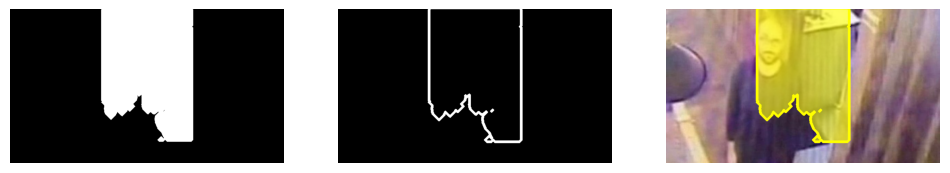

In [77]:

gray_fix = convolution(gray1, kernelSharpening)

h, w = gray_fix.shape

mask = np.zeros_like(gray_fix)

for i in range(h):
    for j in range(w):
        if gray_fix[i,j] > 120:
            mask[i,j] = 255

for i in range(h):
    for j in range(w):
        if j < w*0.35 or j > w*0.65:
            mask[i,j] = 0


for k in range(10):  
    temp = mask.copy()
    for i in range(1, h-1):
        for j in range(1, w-1):
            if temp[i,j] == 255:
                mask[i+1,j] = 255
                mask[i-1,j] = 255
                mask[i,j+1] = 255
                mask[i,j-1] = 255

temp = mask.copy()
for i in range(1, h-1):
    for j in range(1, w-1):
        if temp[i,j] == 255:
            if (temp[i+1,j]==0 or temp[i-1,j]==0 or temp[i,j+1]==0 or temp[i,j-1]==0):
                mask[i,j] = 0

h, w = mask.shape

for i in range(h):
    for j in range(w):
        if (j < w*0.25 or j > w*0.75) or (i > h*0.85):
            mask[i,j] = 0

for k in range(5):
    temp = mask.copy()
    for i in range(1, h-1):
        for j in range(1, w-1):
            if temp[i,j] == 255:
                mask[i+1,j] = 255
                mask[i-1,j] = 255
                mask[i,j+1] = 255
                mask[i,j-1] = 255

visited = np.zeros_like(mask)
best_mask = np.zeros_like(mask)
max_area = 0

for i in range(h):
    for j in range(w):
        if mask[i,j] == 255 and visited[i,j] == 0:

            stack = [(i,j)]
            temp_mask = np.zeros_like(mask)
            area = 0

            while stack:
                x, y = stack.pop()

                if x<0 or x>=h or y<0 or y>=w:
                    continue
                if visited[x,y] == 1 or mask[x,y] == 0:
                    continue

                visited[x,y] = 1
                temp_mask[x,y] = 255
                area += 1

                stack.append((x+1,y))
                stack.append((x-1,y))
                stack.append((x,y+1))
                stack.append((x,y-1))

            if area > max_area:
                max_area = area
                best_mask = temp_mask.copy()

mask = best_mask

ys, xs = np.where(mask == 255)

if len(ys) > 0:
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    tinggi = y_max - y_min
    lebar = x_max - x_min

    if lebar > tinggi:
        mask[:] = 0


edge_only = edge(mask, sobelX, sobelY)
edge_bold = edge_only.copy()

for k in range(3):  
    temp = edge_bold.copy()
    for i in range(1, h-1):
        for j in range(1, w-1):
            if temp[i,j] > 0:
                edge_bold[i+1,j] = 255
                edge_bold[i-1,j] = 255
                edge_bold[i,j+1] = 255
                edge_bold[i,j-1] = 255


overlay = gambarRGB.copy()
alpha = 0.6  
for i in range(h):
    for j in range(w):
        if mask[i,j] == 255:
            overlay[i,j] = (alpha * np.array([255,255,0]) + (1-alpha) * overlay[i,j])

for i in range(h):
    for j in range(w):
        if edge_bold[i,j] > 0:
            overlay[i,j] = [255,255,0]  


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edge_bold, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.axis('off')

plt.show()

# Pas Foto: Deteksi Tepi dan Background Removal
Pada bagian ini proses dimulai dari membaca citra lalu diubah ke grayscale untuk deteksi tepi dengan Sobel, sehingga terlihat garis wajah dan objek. Setelah itu, pemisahan background dilakukan dari kanal RGB, karena background toska punya nilai G dan B lebih tinggi dari R, jadi bagian itu dihapus dan yang tersisa adalah objek (orang). Mask yang dihasilkan kemudian diperbaiki dengan dilasi agar tidak bolong dan median filter supaya lebih halus. Terakhir, background diubah jadi putih, sehingga hasil akhirnya hanya menyisakan objek orang dengan background bersih.

Kesimpulan:

Sobel = deteksi tepi

RGB = pisahin background

Dilasi + median = rapihin

Hasil = objek jelas, background hilang

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11504\1979115820.py:47: RuntimeWarning: overflow encountered in scalar add
  if not (G[i,j] > R[i,j] + 20 and B[i,j] > R[i,j] + 20):


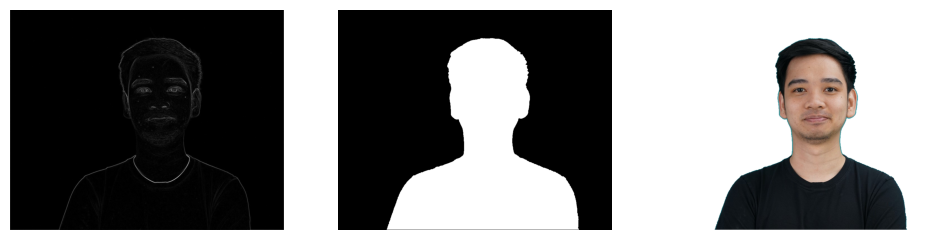

In [80]:
img = cv2.imread('david.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def convolution(img, kernel):
    k = kernel.shape[0]
    pad = k // 2
    padded = np.pad(img, pad, mode='constant')
    out = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+k, j:j+k]
            out[i,j] = np.sum(region * kernel)

    return out

sobelX = np.array(
    [[-1,0,1],
     [-2,0,2],
     [-1,0,1]], 
     dtype=np.float32)
sobelY = np.array(
    [[1,2,1],
     [0,0,0],
     [-1,-2,-1]], 
     dtype=np.float32)

gx = convolution(gray, sobelX)
gy = convolution(gray, sobelY)

edge = np.abs(gx) + np.abs(gy)
edge = edge * 255 / np.max(edge)
edge = edge.astype(np.uint8)

R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

mask = np.zeros((h,w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if not (G[i,j] > R[i,j] + 20 and B[i,j] > R[i,j] + 20):
            mask[i,j] = 255

for k in range(3):
    temp = mask.copy()
    for i in range(1,h-1):
        for j in range(1,w-1):
            if temp[i,j] == 255:
                mask[i+1,j] = 255
                mask[i-1,j] = 255
                mask[i,j+1] = 255
                mask[i,j-1] = 255

mask_med = np.zeros_like(mask)

for i in range(1,h-1):
    for j in range(1,w-1):
        neighbors = [
            mask[i-1,j-1], mask[i-1,j], mask[i-1,j+1],
            mask[i,j-1],   mask[i,j],   mask[i,j+1],
            mask[i+1,j-1], mask[i+1,j], mask[i+1,j+1]
        ]
        neighbors.sort()
        mask_med[i,j] = neighbors[4]  

result = img_rgb.copy()

for i in range(h):
    for j in range(w):
        if mask_med[i,j] == 0:
            result[i,j] = [255,255,255]  # putih

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(edge, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask_med, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result)
plt.axis('off')

plt.show()